In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "efficientnet_crop_disease_model.keras",
    compile=False
)
 
print("Model loaded ✅")




Model loaded ✅


In [2]:
base_model = model.get_layer("efficientnetb0")

print("Base model name:", base_model.name)

Base model name: efficientnetb0


In [3]:
base_model.trainable = True
print("Base model trainable:", base_model.trainable)

Base model trainable: True


In [4]:
# Freeze early layers, keep last 60 layers trainable
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Check kitne layers trainable hain
trainable_count = sum([1 for l in base_model.layers if l.trainable])
print("Trainable layers in base model:", trainable_count)

Trainable layers in base model: 60


In [5]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning ✅")

Model recompiled for fine-tuning ✅


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnet_finetuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks ready ✅")

Callbacks ready ✅


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

BASE_DIR = "plantvillage dataset/plantvillage dataset/color"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Generators ready ✅")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Generators ready ✅


In [8]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

print("Fine-tuning complete ✅")

Epoch 1/10


1358/1358 [==============================] - ETA: 0s - loss: 0.0753 - accuracy: 0.9761
Epoch 1: val_accuracy improved from -inf to 0.98304, saving model to efficientnet_finetuned_best.keras
1358/1358 [==============================] - 3019s 2s/step - loss: 0.0753 - accuracy: 0.9761 - val_loss: 0.0504 - val_accuracy: 0.9830 - lr: 1.0000e-05
Epoch 2/10
1358/1358 [==============================] - ETA: 0s - loss: 0.0569 - accuracy: 0.9820 
Epoch 2: val_accuracy improved from 0.98304 to 0.98534, saving model to efficientnet_finetuned_best.keras
1358/1358 [==============================] - 38207s 28s/step - loss: 0.0569 - accuracy: 0.9820 - val_loss: 0.0457 - val_accuracy: 0.9853 - lr: 1.0000e-05
Epoch 3/10
1358/1358 [==============================] - ETA: 0s - loss: 0.0489 - accuracy: 0.9847
Epoch 3: val_accuracy did not improve from 0.98534
1358/1358 [==============================] - 2302s 2s/step - loss: 0.0489 - accuracy: 0.9847 - val_loss: 0.0422 - val_accuracy: 0.9838 - 

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, 
target_names=list(val_generator.class_indices.keys())))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

340/340 [==============================] - 419s 1s/step

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.96      0.98       126
                                 Apple___Black_rot       1.00      0.98      0.99       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      1.00      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.89      0.90       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       23

In [10]:
model.save("efficientnet_crop_disease_model.keras")


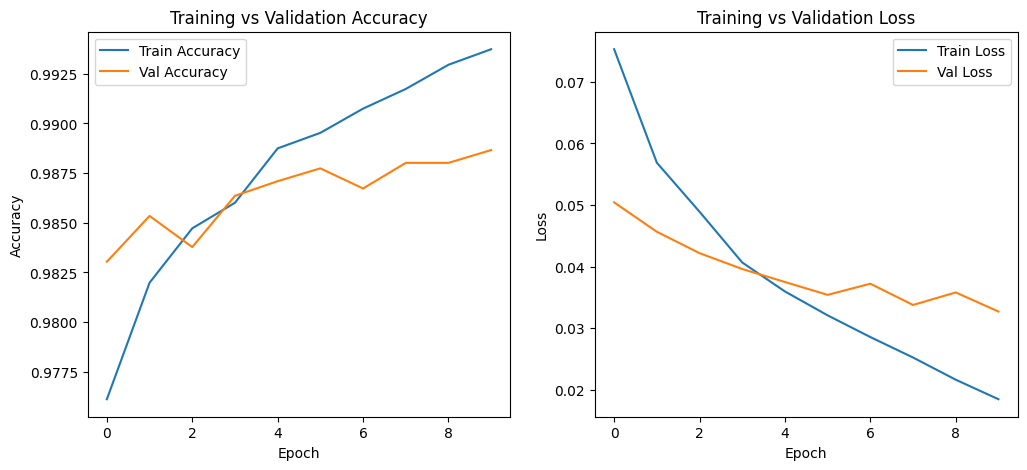

In [14]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_fine.history["accuracy"], label="Train Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_fine.history["loss"], label="Train Loss")
plt.plot(history_fine.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Found 43456 images belonging to 38 classes.
1/1 [==============================] - 4s 4s/step
Predicted Class: Cherry_(including_sour)___Powdery_mildew
Confidence: 100.0 %


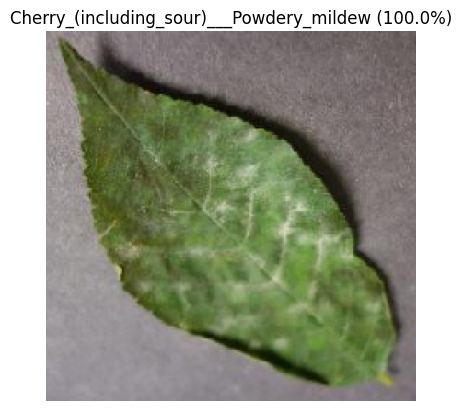

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = load_model("efficientnet_finetuned_best.keras")

BASE_DIR = "plantvillage dataset/plantvillage dataset/color"

datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_directory(
    BASE_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

img_path = "test_leaf.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)

idx = np.argmax(pred)
confidence = np.max(pred)

print("Predicted Class:", class_names[idx])
print("Confidence:", round(confidence*100,2), "%")

plt.imshow(img)
plt.axis("off")
plt.title(f"{class_names[idx]} ({round(confidence*100,2)}%)")
plt.show()

In [20]:
model.save("plantvillage_disease_model.keras")
print("Final model saved ✅")

Final model saved ✅


In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Data collection spreadsheet - Sheet1.csv', 'EfficientNetB0.ipynb', 'efficientnet_crop_disease_model.keras', 'efficientnet_finetuned_best.keras', 'fine_tuning.ipynb', 'newtest_image', 'plantvillage dataset', 'plantvillage_disease_model.keras', 'test_image', 'test_leaf.JPG']


In [3]:
!pip install pandas

In [5]:
import sys
!{sys.executable} -m pip install pandas

In [6]:
import pandas as pd
print("Pandas working ✅")

Pandas working ✅


In [7]:
import pandas as pd
import json

df = pd.read_csv("Data collection spreadsheet - Sheet1.csv")

disease_data = {}

for _, row in df.iterrows():
    disease_name = row["Disease"]
    
    disease_data[disease_name] = {
        "Cause": row["Cause"],
        "Prevention": row["Prevention"],
        "Treatment": row["Treatment"],
        "Pesticide": row["Pesticide"],
        "Organic solution": row["Organic solution"]
    }

with open("disease_data.json", "w", encoding="utf-8") as f:
    json.dump(disease_data, f, indent=4)

print("JSON file created successfully ✅")

JSON file created successfully ✅


Found 43456 images belonging to 38 classes.
1/1 [==============================] - 3s 3s/step
Predicted Disease: Cherry_(including_sour)___Powdery_mildew
Confidence: 100.0 %
No recommendation found in JSON.


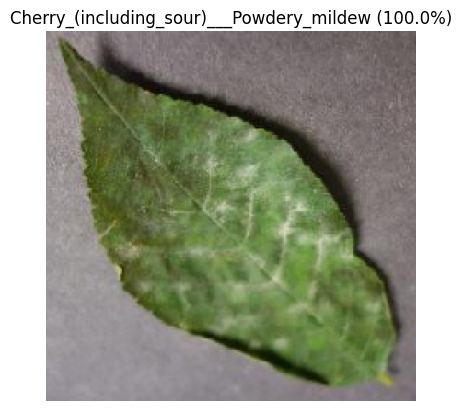

In [9]:
import json
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load fine tuned model
model = load_model("efficientnet_finetuned_best.keras")

# Load JSON database
with open("disease_data.json", "r", encoding="utf-8") as f:
    disease_info = json.load(f)

# Class names (same order as training)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_directory(
    "plantvillage dataset/plantvillage dataset/color",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

# Test image
img_path = "test_leaf.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)
idx = np.argmax(pred)
predicted_class = class_names[idx]
confidence = np.max(pred)

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence*100,2), "%")

# Fetch recommendation from JSON
if predicted_class in disease_info:
    print("\n--- Recommendation ---")
    print("Cause:", disease_info[predicted_class]["Cause"])
    print("Prevention:", disease_info[predicted_class]["Prevention"])
    print("Treatment:", disease_info[predicted_class]["Treatment"])
    print("Pesticide:", disease_info[predicted_class]["Pesticide"])
    print("Organic Solution:", disease_info[predicted_class]["Organic solution"])
else:
    print("No recommendation found in JSON.")

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({round(confidence*100,2)}%)")
plt.show()